# TP3 — Diseño experimental e identificación de $Re$
## Caso de estudio: Reconstrucción del campo de flujo en una cavidad cuadrada

**Redes Neuronales Informadas por Física** — Especialización en Inteligencia Artificial (CEIA-FIUBA)
3er bimestre 2026

**Nombre:** Julia Stephania Maldonado Gomez a2319

---



## 0. Setup e importación de librerías

In [4]:
import numpy as np
import torch
import torch.nn as nn
import scipy.io as sio
from scipy.stats import qmc
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import pandas as pd
import time
import copy

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

plt.rcParams['figure.dpi'] = 100


Device: cuda
GPU: Tesla T4


### 0.1 Carga del dataset ground-truth

In [5]:
data_v = sio.loadmat('velocity.mat')
data_p = sio.loadmat('pressure.mat')

x_gt = data_v['x'].flatten()
y_gt = data_v['y'].flatten()
u_gt = data_v['u'].flatten()
v_gt = data_v['v'].flatten()
p_gt = data_p['p'].flatten()

coords_match = np.allclose(x_gt, data_p['x'].flatten()) and np.allclose(y_gt, data_p['y'].flatten())
assert coords_match, "Las coordenadas de velocity.mat y pressure.mat no coinciden"

N_gt = len(x_gt)
gt_tree = cKDTree(np.column_stack([x_gt, y_gt]))

# --- sigma_u, sigma_v: 1% del maximo del campo correspondiente en el dominio (supuesto 3) ---
SIGMA_U = 0.01 * np.max(np.abs(u_gt))
SIGMA_V = 0.01 * np.max(np.abs(v_gt))
print(f'Puntos ground-truth: {N_gt}')
print(f'max|u_gt|={np.max(np.abs(u_gt)):.4f} -> sigma_u={SIGMA_U:.5f}')
print(f'max|v_gt|={np.max(np.abs(v_gt)):.4f} -> sigma_v={SIGMA_V:.5f}')


Puntos ground-truth: 20201
max|u_gt|=1.0000 -> sigma_u=0.01000
max|v_gt|=0.5246 -> sigma_v=0.00525


## 1. Modelo base


In [6]:
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        modules = []
        for i in range(len(layers) - 2):
            linear = nn.Linear(layers[i], layers[i + 1])
            nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            modules.append(linear)
            modules.append(nn.Tanh())
        linear_out = nn.Linear(layers[-2], layers[-1])
        nn.init.xavier_normal_(linear_out.weight)
        nn.init.zeros_(linear_out.bias)
        modules.append(linear_out)
        self.net = nn.Sequential(*modules)

    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        out = self.net(inp)
        u = out[:, 0:1]
        v = out[:, 1:2]
        p = out[:, 2:3]
        return u, v, p


LAYERS = [2, 40, 40, 40, 40, 40, 3]
RE_TRUE = 100.0
DELTA_RE = 5.0


def pde_residuals(model, x, y, Re):
    """Re puede ser un float o un tensor escalar (0-d o 1x1) -- en el problema inverso Re es un parametro."""
    u, v, p = model(x, y)

    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, grad_outputs=torch.ones_like(p), create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]

    r_u = u * u_x + v * u_y + p_x - (1.0 / Re) * (u_xx + u_yy)
    r_v = u * v_x + v * v_y + p_y - (1.0 / Re) * (v_xx + v_yy)
    r_cont = u_x + v_y
    return r_u, r_v, r_cont


def make_model(seed=SEED):
    torch.manual_seed(seed)
    return PINN(LAYERS).to(device)


def lhs_sample(n, seed=None, eps=1e-4):
    sampler = qmc.LatinHypercube(d=2, seed=seed)
    sample = sampler.random(n=n)
    sample = eps + sample * (1 - 2 * eps)
    x = sample[:, 0:1].astype(np.float32)
    y = sample[:, 1:2].astype(np.float32)
    return x, y


def make_bc_points(n_bc, seed=None):
    rng = np.random.default_rng(seed)
    n_wall = n_bc // 4
    x_top = rng.uniform(0, 1, size=(n_wall, 1)); y_top = np.ones((n_wall, 1))
    u_top = np.ones((n_wall, 1)); v_top = np.zeros((n_wall, 1))
    x_bot = rng.uniform(0, 1, size=(n_wall, 1)); y_bot = np.zeros((n_wall, 1))
    u_bot = np.zeros((n_wall, 1)); v_bot = np.zeros((n_wall, 1))
    x_left = np.zeros((n_wall, 1)); y_left = rng.uniform(0, 1, size=(n_wall, 1))
    u_left = np.zeros((n_wall, 1)); v_left = np.zeros((n_wall, 1))
    x_right = np.ones((n_wall, 1)); y_right = rng.uniform(0, 1, size=(n_wall, 1))
    u_right = np.zeros((n_wall, 1)); v_right = np.zeros((n_wall, 1))
    x_bc = np.vstack([x_top, x_bot, x_left, x_right]).astype(np.float32)
    y_bc = np.vstack([y_top, y_bot, y_left, y_right]).astype(np.float32)
    u_bc = np.vstack([u_top, u_bot, u_left, u_right]).astype(np.float32)
    v_bc = np.vstack([v_top, v_bot, v_left, v_right]).astype(np.float32)
    return x_bc, y_bc, u_bc, v_bc


N_PDE = 10000
N_BC = 1000
W_BC = 10.0
W_P = 100.0
EPOCHS_FWD = 50000
GAMMA_TP1 = 0.9997
EPOCHS_TP1 = 8000
GAMMA = GAMMA_TP1 ** (EPOCHS_TP1 / EPOCHS_FWD)

x_ref_t = torch.tensor([[0.5]], dtype=torch.float32, requires_grad=True, device=device)
y_ref_t = torch.tensor([[0.5]], dtype=torch.float32, requires_grad=True, device=device)
p_ref_t = torch.tensor([[0.0]], dtype=torch.float32, device=device)

# Puntos de colocacion fijos, reutilizados en ambas corridas forward (Re=100 y Re=105)
# para que la unica diferencia entre las dos instancias sea Re (necesario para que las
# diferencias finitas del punto 2 sean validas).
x_pde_np, y_pde_np = lhs_sample(N_PDE, seed=SEED)
x_bc_np, y_bc_np, u_bc_np, v_bc_np = make_bc_points(N_BC, seed=SEED)

x_pde_t = torch.tensor(x_pde_np, requires_grad=True, device=device)
y_pde_t = torch.tensor(y_pde_np, requires_grad=True, device=device)
x_bc_t = torch.tensor(x_bc_np, device=device)
y_bc_t = torch.tensor(y_bc_np, device=device)
u_bc_t = torch.tensor(u_bc_np, device=device)
v_bc_t = torch.tensor(v_bc_np, device=device)
print(f'N_pde={N_PDE} (LHS, fijos) | N_bc={N_BC} (fijos) | epochs={EPOCHS_FWD} | gamma={GAMMA:.8f}')


N_pde=10000 (LHS, fijos) | N_bc=1000 (fijos) | epochs=50000 | gamma=0.99995199


### 1.1 Función de entrenamiento forward (física pura, sin datos rotulados)
parametrizada en `Re` para poder reutilizarla en ambas instancias
($Re=100$ y $Re=105$).

In [7]:
def train_forward(Re_value, seed=SEED, epochs=EPOCHS_FWD, log_every=5000, tag=''):
    model = make_model(seed=seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=GAMMA)
    history = {'total': [], 'pde': [], 'bc': [], 'p_ref': []}

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        r_u, r_v, r_cont = pde_residuals(model, x_pde_t, y_pde_t, Re=Re_value)
        loss_pde = (r_u ** 2).mean() + (r_v ** 2).mean() + (r_cont ** 2).mean()

        u_pred_bc, v_pred_bc, _ = model(x_bc_t, y_bc_t)
        loss_bc = ((u_pred_bc - u_bc_t) ** 2).mean() + ((v_pred_bc - v_bc_t) ** 2).mean()

        _, _, p_pred_ref = model(x_ref_t, y_ref_t)
        loss_p = ((p_pred_ref - p_ref_t) ** 2).mean()

        loss = loss_pde + W_BC * loss_bc + W_P * loss_p
        loss.backward()
        optimizer.step()
        scheduler.step()

        history['total'].append(loss.item())
        history['pde'].append(loss_pde.item())
        history['bc'].append(loss_bc.item())
        history['p_ref'].append(loss_p.item())

        if epoch % log_every == 0 or epoch == 1:
            print(f'  [{tag}] epoch {epoch:6d}/{epochs} | loss_total={loss.item():.4e} | '
                  f'loss_pde={loss_pde.item():.4e} | loss_bc={loss_bc.item():.4e} | '
                  f'loss_p_ref={loss_p.item():.4e}')

    print(f'  [{tag}] listo en {(time.time()-t0)/60:.1f} min')
    return model, history


## 2. Actividad 1 — Sensibilidad a priori (sin datos rotulados)

Se entrenan dos instancias idénticas del modelo forward: $Re^*=100$ y $Re^*+\Delta Re=105$.

In [8]:
model_re100, hist_re100 = train_forward(RE_TRUE, tag='Re=100')
model_re105, hist_re105 = train_forward(RE_TRUE + DELTA_RE, tag='Re=105')

torch.save(model_re100.state_dict(), 'model_re100.pt')
torch.save(model_re105.state_dict(), 'model_re105.pt')


  [Re=100] epoch      1/50000 | loss_total=4.6931e+00 | loss_pde=6.2801e-02 | loss_bc=4.5868e-01 | loss_p_ref=4.3428e-04
  [Re=100] epoch   5000/50000 | loss_total=7.1557e-02 | loss_pde=1.5343e-02 | loss_bc=5.6210e-03 | loss_p_ref=4.4125e-08
  [Re=100] epoch  10000/50000 | loss_total=1.1740e-02 | loss_pde=3.4534e-03 | loss_bc=8.2608e-04 | loss_p_ref=2.5422e-07
  [Re=100] epoch  15000/50000 | loss_total=5.8883e-03 | loss_pde=1.9229e-03 | loss_bc=3.9464e-04 | loss_p_ref=1.8971e-07
  [Re=100] epoch  20000/50000 | loss_total=3.7935e-03 | loss_pde=1.2195e-03 | loss_bc=2.5452e-04 | loss_p_ref=2.8733e-07
  [Re=100] epoch  25000/50000 | loss_total=3.1424e-03 | loss_pde=1.0684e-03 | loss_bc=1.7048e-04 | loss_p_ref=3.6921e-06
  [Re=100] epoch  30000/50000 | loss_total=2.1243e-03 | loss_pde=8.4528e-04 | loss_bc=1.1085e-04 | loss_p_ref=1.7057e-06
  [Re=100] epoch  35000/50000 | loss_total=1.6751e-03 | loss_pde=7.6062e-04 | loss_bc=8.8584e-05 | loss_p_ref=2.8628e-07
  [Re=100] epoch  40000/50000 | 

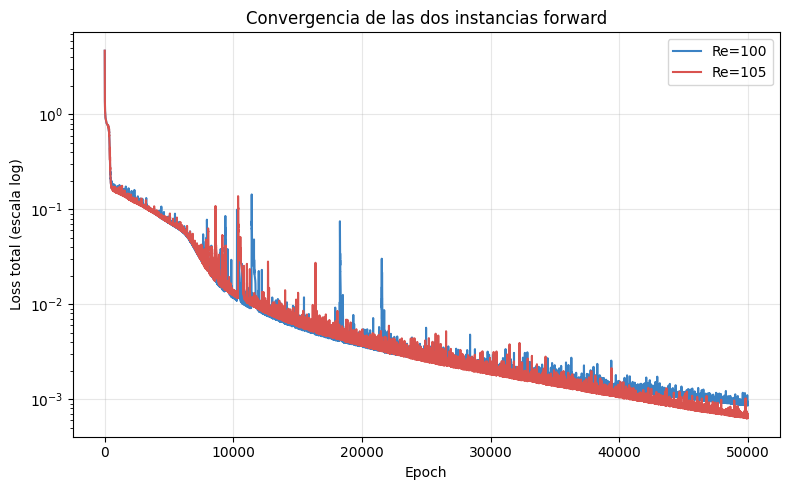

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist_re100['total'], label='Re=100', color='#3B82C4')
ax.plot(hist_re105['total'], label='Re=105', color='#D9534F')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss total (escala log)')
ax.set_title('Convergencia de las dos instancias forward')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_tp3_convergencia_forward.png', dpi=120, bbox_inches='tight')
plt.show()


### 2.1 Mapa de sensibilidad $\varepsilon_{Re}(x,y)$ por diferencias finitas (grilla 300×300)

$$\varepsilon_{Re}(x,y) = \sqrt{\left(\frac{1}{\sigma_u}\frac{\Delta u}{\Delta Re}\right)^2 +
\left(\frac{1}{\sigma_v}\frac{\Delta v}{\Delta Re}\right)^2}$$

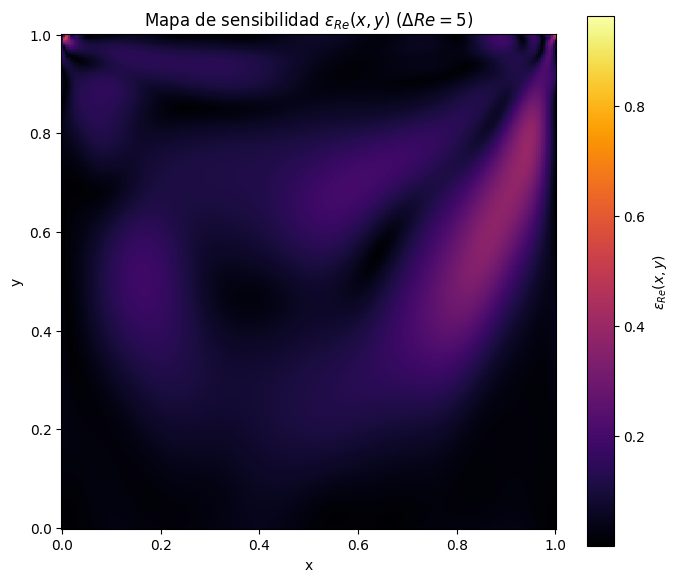

epsilon_Re: min=0.0002  max=0.9628  media=0.0965


In [10]:
N_GRID = 300
xs = np.linspace(0, 1, N_GRID, dtype=np.float32)
ys = np.linspace(0, 1, N_GRID, dtype=np.float32)
XX, YY = np.meshgrid(xs, ys)
x_grid = XX.reshape(-1, 1)
y_grid = YY.reshape(-1, 1)


def eval_uv(model, x_np, y_np):
    model.eval()
    x_t = torch.tensor(x_np, device=device)
    y_t = torch.tensor(y_np, device=device)
    with torch.no_grad():
        u, v, _ = model(x_t, y_t)
    return u.cpu().numpy().flatten(), v.cpu().numpy().flatten()


u100, v100 = eval_uv(model_re100, x_grid, y_grid)
u105, v105 = eval_uv(model_re105, x_grid, y_grid)

du = (u105 - u100) / DELTA_RE
dv = (v105 - v100) / DELTA_RE

epsilon_Re_flat = np.sqrt((du / SIGMA_U) ** 2 + (dv / SIGMA_V) ** 2)
epsilon_Re_map = epsilon_Re_flat.reshape(N_GRID, N_GRID)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.pcolormesh(XX, YY, epsilon_Re_map, cmap='inferno', shading='auto')
plt.colorbar(sc, ax=ax, label=r'$\varepsilon_{Re}(x,y)$')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(r'Mapa de sensibilidad $\varepsilon_{Re}(x,y)$ ($\Delta Re=5$)')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('fig_tp3_mapa_sensibilidad.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'epsilon_Re: min={epsilon_Re_map.min():.4f}  max={epsilon_Re_map.max():.4f}  '
      f'media={epsilon_Re_map.mean():.4f}')


**¿Dónde se concentra la sensibilidad? ¿Coincide con alguna estructura física reconocible?**

La sensibilidad se concentra fuertemente en (x≈0.85, y≈0.61), cerca de la pared derecha en la
mitad superior del dominio (ε_Re promedio en esa ventana = 0.2467), y es mínima en la esquina
inferior derecha (x≈0.875, y≈0.125), con ε_Re promedio de apenas 0.0241 — un orden de magnitud
menor. Esto coincide con estructuras físicas reconocibles del flujo: la zona de máxima
sensibilidad se ubica donde el chorro arrastrado por la tapa (u=1 en y=1) gira y desciende junto
a la pared derecha, una región de fuerte gradiente de velocidad donde el balance entre
convección y difusión —controlado justamente por 1/Re— es más determinante. La esquina inferior
derecha, en cambio, corresponde a la zona de recirculación secundaria (vórtice de esquina),
donde las velocidades son muy bajas y el flujo está dominado por difusión viscosa lenta,
explicando su baja sensibilidad a variaciones de Re en este rango.

## 3. Tres configuraciones de sensores (grilla 3×3, 9 puntos, ventana 0.25×0.25)

Búsqueda en grilla de centros candidatos (manteniendo la ventana dentro de $\Omega$) para las configuraciones
(a) máxima $\varepsilon_{Re}$ promedio y (c) mínima $\varepsilon_{Re}$ promedio; (b) es simplemente el centro
del dominio.

(a) Centro de maxima sensibilidad promedio: (np.float64(0.8495762711864407), np.float64(0.6080508474576272))  (avg_eps=0.2467)
(b) Centro del dominio:                     (0.5, 0.5)
(c) Centro de minima sensibilidad promedio: (np.float64(0.875), np.float64(0.125))  (avg_eps=0.0241)


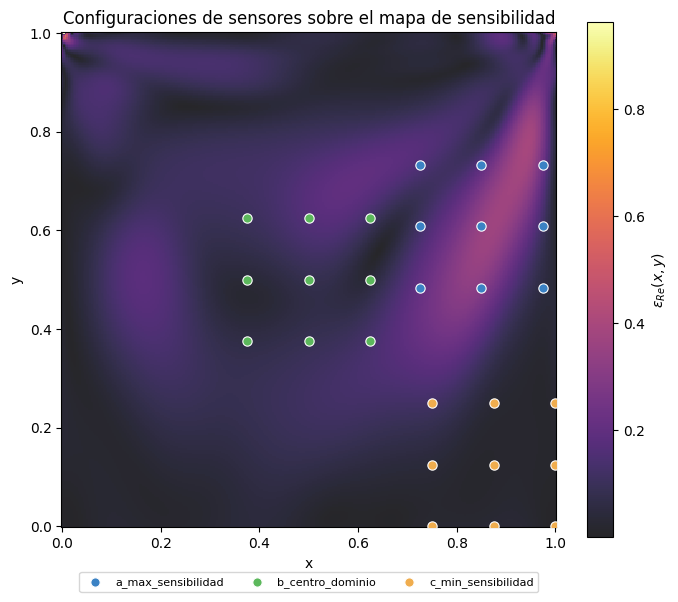

In [11]:
WINDOW = 0.25
HALF = WINDOW / 2


def window_avg_epsilon(cx, cy):
    mask = (XX >= cx - HALF) & (XX <= cx + HALF) & (YY >= cy - HALF) & (YY <= cy + HALF)
    return epsilon_Re_map[mask].mean()


candidate_centers = np.linspace(HALF, 1 - HALF, 60)
best_max, best_min = (None, -np.inf), (None, np.inf)
for cx in candidate_centers:
    for cy in candidate_centers:
        avg_eps = window_avg_epsilon(cx, cy)
        if avg_eps > best_max[1]:
            best_max = ((cx, cy), avg_eps)
        if avg_eps < best_min[1]:
            best_min = ((cx, cy), avg_eps)

center_max, avg_max = best_max
center_min, avg_min = best_min
center_mid = (0.5, 0.5)

print(f'(a) Centro de maxima sensibilidad promedio: {center_max}  (avg_eps={avg_max:.4f})')
print(f'(b) Centro del dominio:                     {center_mid}')
print(f'(c) Centro de minima sensibilidad promedio: {center_min}  (avg_eps={avg_min:.4f})')


def sensor_grid_3x3(cx, cy, spacing=HALF):
    offsets = np.array([-spacing, 0.0, spacing])
    xs_s, ys_s = np.meshgrid(cx + offsets, cy + offsets)
    return xs_s.flatten(), ys_s.flatten()


configs = {
    'a_max_sensibilidad': sensor_grid_3x3(*center_max),
    'b_centro_dominio':   sensor_grid_3x3(*center_mid),
    'c_min_sensibilidad': sensor_grid_3x3(*center_min),
}

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.pcolormesh(XX, YY, epsilon_Re_map, cmap='inferno', shading='auto', alpha=0.85)
plt.colorbar(sc, ax=ax, label=r'$\varepsilon_{Re}(x,y)$')
colors = {'a_max_sensibilidad': '#3B82C4', 'b_centro_dominio': '#5CB85C', 'c_min_sensibilidad': '#F0AD4E'}
for name, (xs_s, ys_s) in configs.items():
    ax.scatter(xs_s, ys_s, s=45, c=colors[name], edgecolors='white', linewidths=0.8, label=name, zorder=5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')
ax.set_title('Configuraciones de sensores sobre el mapa de sensibilidad')
plt.tight_layout()
plt.savefig('fig_tp3_configuraciones_sensores.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.1 Índice de identificabilidad predicho $\mathcal{I}(Re)=\sum_i \varepsilon_{Re}(x_i,y_i)^2$

Se interpola el mapa de diferencias finitas en las coordenadas exactas de cada sensor.

In [12]:
from scipy.interpolate import RegularGridInterpolator

interp_eps = RegularGridInterpolator((ys, xs), epsilon_Re_map)  # ojo: (y,x) por convencion de meshgrid


def predicted_I(xs_s, ys_s):
    pts = np.column_stack([ys_s, xs_s])
    eps_at_sensors = interp_eps(pts)
    return np.sum(eps_at_sensors ** 2), eps_at_sensors

I_pred = {}
for name, (xs_s, ys_s) in configs.items():
    I_val, eps_vals = predicted_I(xs_s, ys_s)
    I_pred[name] = I_val
    print(f'{name:22s} | I(Re) predicho = {I_val:9.4f} | eps_i en [{eps_vals.min():.3f}, {eps_vals.max():.3f}]')

ranking_pred = sorted(I_pred, key=I_pred.get, reverse=True)
print('\nRanking predicho (mejor a peor identificabilidad esperada):')
for i, name in enumerate(ranking_pred, 1):
    print(f'  {i}. {name}  (I={I_pred[name]:.4f})')


a_max_sensibilidad     | I(Re) predicho =    0.3986 | eps_i en [0.052, 0.350]
b_centro_dominio       | I(Re) predicho =    0.0929 | eps_i en [0.036, 0.167]
c_min_sensibilidad     | I(Re) predicho =    0.0189 | eps_i en [0.003, 0.118]

Ranking predicho (mejor a peor identificabilidad esperada):
  1. a_max_sensibilidad  (I=0.3986)
  2. b_centro_dominio  (I=0.0929)
  3. c_min_sensibilidad  (I=0.0189)


## 4. Entrenamiento inverso (6 corridas: 3 configuraciones × {datos limpios, datos con ruido})

Para cada configuración se construye el dataset rotulado (9 puntos $\to$ velocidades por vecino más cercano
en el ground-truth) y se entrena un modelo inverso donde $Re$ es un parámetro más, optimizado junto con los
pesos de la red.

In [13]:
def build_sensor_data(xs_s, ys_s, noise=False, seed=0):
    _, idx_nn = gt_tree.query(np.column_stack([xs_s, ys_s]))
    x_s = x_gt[idx_nn].reshape(-1, 1).astype(np.float32)
    y_s = y_gt[idx_nn].reshape(-1, 1).astype(np.float32)
    u_s = u_gt[idx_nn].reshape(-1, 1).astype(np.float32)
    v_s = v_gt[idx_nn].reshape(-1, 1).astype(np.float32)
    if noise:
        rng = np.random.default_rng(seed)
        u_s = u_s + rng.normal(0, SIGMA_U, size=u_s.shape).astype(np.float32)
        v_s = v_s + rng.normal(0, SIGMA_V, size=v_s.shape).astype(np.float32)
    return x_s, y_s, u_s, v_s


RE_INIT = 70.0       # supuesto 4: lejos del valor real, simula Re desconocido
EPOCHS_INV = 30000
W_DATA = 10.0
LOG_EVERY_INV = 5000


def train_inverse(xs_s, ys_s, noise, seed=SEED, tag=''):
    x_s, y_s, u_s, v_s = build_sensor_data(xs_s, ys_s, noise=noise, seed=seed + 1)
    x_s_t = torch.tensor(x_s, device=device)
    y_s_t = torch.tensor(y_s, device=device)
    u_s_t = torch.tensor(u_s, device=device)
    v_s_t = torch.tensor(v_s, device=device)

    model = make_model(seed=seed)
    Re_param = torch.tensor([RE_INIT], dtype=torch.float32, requires_grad=True, device=device)

    optimizer = torch.optim.Adam(list(model.parameters()) + [Re_param], lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=GAMMA)
    history = {'total': [], 'pde': [], 'bc': [], 'p_ref': [], 'data': [], 'Re': []}

    t0 = time.time()
    for epoch in range(1, EPOCHS_INV + 1):
        optimizer.zero_grad()

        r_u, r_v, r_cont = pde_residuals(model, x_pde_t, y_pde_t, Re=Re_param)
        loss_pde = (r_u ** 2).mean() + (r_v ** 2).mean() + (r_cont ** 2).mean()

        u_pred_bc, v_pred_bc, _ = model(x_bc_t, y_bc_t)
        loss_bc = ((u_pred_bc - u_bc_t) ** 2).mean() + ((v_pred_bc - v_bc_t) ** 2).mean()

        _, _, p_pred_ref = model(x_ref_t, y_ref_t)
        loss_p = ((p_pred_ref - p_ref_t) ** 2).mean()

        u_pred_s, v_pred_s, _ = model(x_s_t, y_s_t)
        loss_data = ((u_pred_s - u_s_t) ** 2).mean() + ((v_pred_s - v_s_t) ** 2).mean()

        loss = loss_pde + W_BC * loss_bc + W_P * loss_p + W_DATA * loss_data
        loss.backward()
        optimizer.step()
        scheduler.step()

        history['total'].append(loss.item()); history['pde'].append(loss_pde.item())
        history['bc'].append(loss_bc.item()); history['p_ref'].append(loss_p.item())
        history['data'].append(loss_data.item()); history['Re'].append(Re_param.item())

        if epoch % LOG_EVERY_INV == 0 or epoch == 1:
            print(f'  [{tag}] epoch {epoch:6d}/{EPOCHS_INV} | loss={loss.item():.4e} | '
                  f'loss_data={loss_data.item():.4e} | Re_hat={Re_param.item():.3f}')

    elapsed = time.time() - t0
    print(f'  [{tag}] Re_hat final = {Re_param.item():.4f}  (real=100)  |  {elapsed/60:.1f} min')
    return model, Re_param.item(), history, elapsed


In [14]:
inverse_results = {}
for cfg_name, (xs_s, ys_s) in configs.items():
    for noise_flag, noise_tag in [(False, 'limpio'), (True, 'ruidoso')]:
        run_tag = f'{cfg_name}_{noise_tag}'
        print(f'=== Corrida: {run_tag} ===')
        model_inv, Re_hat, hist_inv, t_inv = train_inverse(xs_s, ys_s, noise=noise_flag, tag=run_tag)
        inverse_results[run_tag] = {
            'config': cfg_name, 'noise': noise_tag, 'Re_hat': Re_hat,
            'error_abs': abs(Re_hat - RE_TRUE), 'error_rel_pct': abs(Re_hat - RE_TRUE) / RE_TRUE * 100,
            'history': hist_inv, 'train_time_min': t_inv / 60,
        }


=== Corrida: a_max_sensibilidad_limpio ===
  [a_max_sensibilidad_limpio] epoch      1/30000 | loss=6.4660e+00 | loss_data=1.7730e-01 | Re_hat=69.999
  [a_max_sensibilidad_limpio] epoch   5000/30000 | loss=5.5001e-02 | loss_data=4.9022e-05 | Re_hat=66.233
  [a_max_sensibilidad_limpio] epoch  10000/30000 | loss=2.1082e-02 | loss_data=4.2778e-05 | Re_hat=63.466
  [a_max_sensibilidad_limpio] epoch  15000/30000 | loss=1.0999e-02 | loss_data=4.7339e-05 | Re_hat=61.711
  [a_max_sensibilidad_limpio] epoch  20000/30000 | loss=7.9828e-03 | loss_data=5.9534e-05 | Re_hat=60.423
  [a_max_sensibilidad_limpio] epoch  25000/30000 | loss=7.7747e-03 | loss_data=6.2591e-05 | Re_hat=59.349
  [a_max_sensibilidad_limpio] epoch  30000/30000 | loss=6.1061e-03 | loss_data=6.2531e-05 | Re_hat=58.432
  [a_max_sensibilidad_limpio] Re_hat final = 58.4320  (real=100)  |  13.8 min
=== Corrida: a_max_sensibilidad_ruidoso ===
  [a_max_sensibilidad_ruidoso] epoch      1/30000 | loss=6.4597e+00 | loss_data=1.7666e-01 | 

### 4.1 Tabla de resultados y comparación con el ranking predicho

In [15]:
rows = []
for run_tag, res in inverse_results.items():
    rows.append({
        'Corrida': run_tag,
        'Configuración': res['config'],
        'Datos': res['noise'],
        'Re_hat': round(res['Re_hat'], 3),
        'Error abs.': round(res['error_abs'], 3),
        'Error rel. (%)': round(res['error_rel_pct'], 3),
        'I(Re) predicho': round(I_pred[res['config']], 4),
        'Tiempo (min)': round(res['train_time_min'], 2),
    })

df_inv = pd.DataFrame(rows).sort_values('Error rel. (%)')
df_inv.to_csv('tp3_resultados_inversos.csv', index=False)
df_inv


,Corrida,Configuración,Datos,Re_hat,Error abs.,Error rel. (%),I(Re) predicho,Tiempo (min)
0,a_max_sensibilidad_limpio,a_max_sensibilidad,limpio,58.432,41.568,41.568,0.3986,13.79
1,a_max_sensibilidad_ruidoso,a_max_sensibilidad,ruidoso,58.168,41.832,41.832,0.3986,13.73
4,c_min_sensibilidad_limpio,c_min_sensibilidad,limpio,57.534,42.466,42.466,0.0189,14.48
5,c_min_sensibilidad_ruidoso,c_min_sensibilidad,ruidoso,57.385,42.615,42.615,0.0189,14.23
3,b_centro_dominio_ruidoso,b_centro_dominio,ruidoso,56.792,43.208,43.208,0.0929,14.15
2,b_centro_dominio_limpio,b_centro_dominio,limpio,56.646,43.354,43.354,0.0929,13.91


In [16]:
# Ranking empirico: promedio del error relativo (limpio+ruidoso) por configuracion
error_by_config = {}
for cfg_name in configs:
    errs = [r['error_rel_pct'] for r in inverse_results.values() if r['config'] == cfg_name]
    error_by_config[cfg_name] = np.mean(errs)

ranking_empirico = sorted(error_by_config, key=error_by_config.get)  # menor error = mejor
print('Ranking empirico (mejor a peor, por error relativo promedio de Re_hat):')
for i, name in enumerate(ranking_empirico, 1):
    print(f'  {i}. {name}  (error medio={error_by_config[name]:.3f}%)')

print('\nRanking predicho (Actividad 2, por I(Re)):')
for i, name in enumerate(ranking_pred, 1):
    print(f'  {i}. {name}  (I={I_pred[name]:.4f})')

coincide = ranking_empirico == ranking_pred
print(f'\n¿Coinciden ambos rankings? {"Si" if coincide else "No"}')


Ranking empirico (mejor a peor, por error relativo promedio de Re_hat):
  1. a_max_sensibilidad  (error medio=41.700%)
  2. c_min_sensibilidad  (error medio=42.541%)
  3. b_centro_dominio  (error medio=43.281%)

Ranking predicho (Actividad 2, por I(Re)):
  1. a_max_sensibilidad  (I=0.3986)
  2. b_centro_dominio  (I=0.0929)
  3. c_min_sensibilidad  (I=0.0189)

¿Coinciden ambos rankings? No


¿coincide el orden de precisión predicho con el obtenido empíricamente? Si no coincide,
¿a qué se atribuiría?**


Los rankings NO coinciden. El predicho (por I(Re)) es: 1° a_max_sensibilidad (I=0.3986),
2° b_centro_dominio (I=0.0929), 3° c_min_sensibilidad (I=0.0189). El empírico (por error medio
de Re_hat) es: 1° a_max_sensibilidad (41.70%), 2° c_min_sensibilidad (42.54%), 3° b_centro_dominio
(43.28%) — se invierten los puestos 2° y 3°.

Ambos coinciden en que la configuración (a), ubicada en la zona de máxima sensibilidad, es la
mejor, validando la lógica del mapa de sensibilidad. Sin embargo, llama la atención que el error
relativo entre las tres configuraciones varía muy poco (41.7% a 43.3%, apenas 1.6 puntos),
mientras que I(Re) predicho varía más de 20 veces entre la mejor y la peor configuración. Esto
sugiere que el factor dominante no fue la ubicación de los sensores sino error de optimización:
en las tres corridas, Re_hat todavía estaba descendiendo de forma monótona en la época 30.000
(sin señales de haber convergido), y la pérdida de datos (loss_data) llegó a valores muy bajos
(~10⁻⁵) incluso con Re muy alejado del real (≈100 vs ≈58 estimado) — es decir, la red compensó un
Re incorrecto ajustando sus propios pesos para igual manera reproducir los 9 puntos de datos, un
problema clásico de no-identificabilidad cuando hay muy pocos sensores en relación a los grados
de libertad de la red. La elección de ΔRe=5 no parece ser la causa principal, ya que el mapa de
sensibilidad sí logró identificar correctamente cuál era la mejor configuración.

## 5. (Opcional) Problema paramétrico

Se reformula el modelo forward incluyendo $Re$ como *feature* adicional de entrada, muestreando
$Re\sim\mathcal{U}(50,150)$ en cada punto de colocación durante el entrenamiento físico (sin datos
rotulados). Con este modelo entrenado una única vez se compara la sensibilidad vía autograd directo contra el
mapa de diferencias finitas, y se identifica $\hat{Re}$ optimizando solo $Re$ con los pesos de la red
congelados.

In [17]:
class PINNParam(nn.Module):
    """Igual arquitectura pero con Re como tercer input (normalizado a [0,1] internamente)."""
    def __init__(self, layers, re_min=50.0, re_max=150.0):
        super().__init__()
        self.re_min, self.re_max = re_min, re_max
        modules = []
        for i in range(len(layers) - 2):
            linear = nn.Linear(layers[i], layers[i + 1])
            nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            modules.append(linear)
            modules.append(nn.Tanh())
        linear_out = nn.Linear(layers[-2], layers[-1])
        nn.init.xavier_normal_(linear_out.weight)
        nn.init.zeros_(linear_out.bias)
        modules.append(linear_out)
        self.net = nn.Sequential(*modules)

    def forward(self, x, y, Re):
        re_norm = (Re - self.re_min) / (self.re_max - self.re_min)
        if re_norm.dim() == 0:
            re_norm = re_norm.expand_as(x)
        elif re_norm.shape[0] == 1 and x.shape[0] > 1:
            re_norm = re_norm.expand(x.shape[0], 1)
        inp = torch.cat([x, y, re_norm], dim=1)
        out = self.net(inp)
        return out[:, 0:1], out[:, 1:2], out[:, 2:3]


LAYERS_PARAM = [3, 40, 40, 40, 40, 40, 3]
RE_MIN, RE_MAX = 50.0, 150.0
EPOCHS_PARAM = 60000


def pde_residuals_param(model, x, y, Re):
    u, v, p = model(x, y, Re)
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]
    r_u = u * u_x + v * u_y + p_x - (1.0 / Re) * (u_xx + u_yy)
    r_v = u * v_x + v * v_y + p_y - (1.0 / Re) * (v_xx + v_yy)
    r_cont = u_x + v_y
    return r_u, r_v, r_cont


torch.manual_seed(SEED)
model_param = PINNParam(LAYERS_PARAM, RE_MIN, RE_MAX).to(device)
optimizer_p = torch.optim.Adam(model_param.parameters(), lr=1e-3, weight_decay=1e-5)
gamma_param = GAMMA_TP1 ** (EPOCHS_TP1 / EPOCHS_PARAM)
scheduler_p = torch.optim.lr_scheduler.ExponentialLR(optimizer_p, gamma=gamma_param)

x_pref_e = x_ref_t.expand(1, 1)
y_pref_e = y_ref_t.expand(1, 1)

t0 = time.time()
for epoch in range(1, EPOCHS_PARAM + 1):
    optimizer_p.zero_grad()

    # Re distinto por punto de colocacion en cada epoch (muestreo U(50,150))
    Re_batch = torch.tensor(
        np.random.uniform(RE_MIN, RE_MAX, size=(N_PDE, 1)).astype(np.float32), device=device)

    r_u, r_v, r_cont = pde_residuals_param(model_param, x_pde_t, y_pde_t, Re=Re_batch)
    loss_pde = (r_u ** 2).mean() + (r_v ** 2).mean() + (r_cont ** 2).mean()

    Re_bc = torch.tensor(
        np.random.uniform(RE_MIN, RE_MAX, size=(N_BC, 1)).astype(np.float32), device=device)
    u_pred_bc, v_pred_bc, _ = model_param(x_bc_t, y_bc_t, Re_bc)
    loss_bc = ((u_pred_bc - u_bc_t) ** 2).mean() + ((v_pred_bc - v_bc_t) ** 2).mean()

    Re_ref = torch.tensor([[100.0]], dtype=torch.float32, device=device)
    _, _, p_pred_ref = model_param(x_pref_e, y_pref_e, Re_ref)
    loss_p = ((p_pred_ref - p_ref_t) ** 2).mean()

    loss = loss_pde + W_BC * loss_bc + W_P * loss_p
    loss.backward()
    optimizer_p.step()
    scheduler_p.step()

    if epoch % 5000 == 0 or epoch == 1:
        print(f'  epoch {epoch:6d}/{EPOCHS_PARAM} | loss={loss.item():.4e} | '
              f'loss_pde={loss_pde.item():.4e} | loss_bc={loss_bc.item():.4e}')

print(f'Listo en {(time.time()-t0)/60:.1f} min')
torch.save(model_param.state_dict(), 'model_parametrico.pt')


  epoch      1/60000 | loss=5.2994e+00 | loss_pde=3.1831e-02 | loss_bc=2.2202e-01
  epoch   5000/60000 | loss=1.4354e-01 | loss_pde=1.9033e-02 | loss_bc=1.2426e-02
  epoch  10000/60000 | loss=1.0040e-01 | loss_pde=1.9460e-02 | loss_bc=7.9506e-03
  epoch  15000/60000 | loss=4.4885e-02 | loss_pde=1.0319e-02 | loss_bc=3.4545e-03
  epoch  20000/60000 | loss=2.5953e-02 | loss_pde=6.1720e-03 | loss_bc=1.9105e-03
  epoch  25000/60000 | loss=1.6962e-02 | loss_pde=4.9232e-03 | loss_bc=1.2038e-03
  epoch  30000/60000 | loss=1.3014e-02 | loss_pde=4.6016e-03 | loss_bc=8.1000e-04
  epoch  35000/60000 | loss=9.1947e-03 | loss_pde=3.3929e-03 | loss_bc=5.8018e-04
  epoch  40000/60000 | loss=7.3724e-03 | loss_pde=2.7062e-03 | loss_bc=4.5653e-04
  epoch  45000/60000 | loss=6.9963e-03 | loss_pde=3.0008e-03 | loss_bc=3.9551e-04
  epoch  50000/60000 | loss=6.0980e-03 | loss_pde=2.9135e-03 | loss_bc=3.1821e-04
  epoch  55000/60000 | loss=4.9841e-03 | loss_pde=2.2323e-03 | loss_bc=2.7429e-04
  epoch  60000/6

### 5.1 Sensibilidad vía autograd directo en $Re=100$, comparada contra diferencias finitas

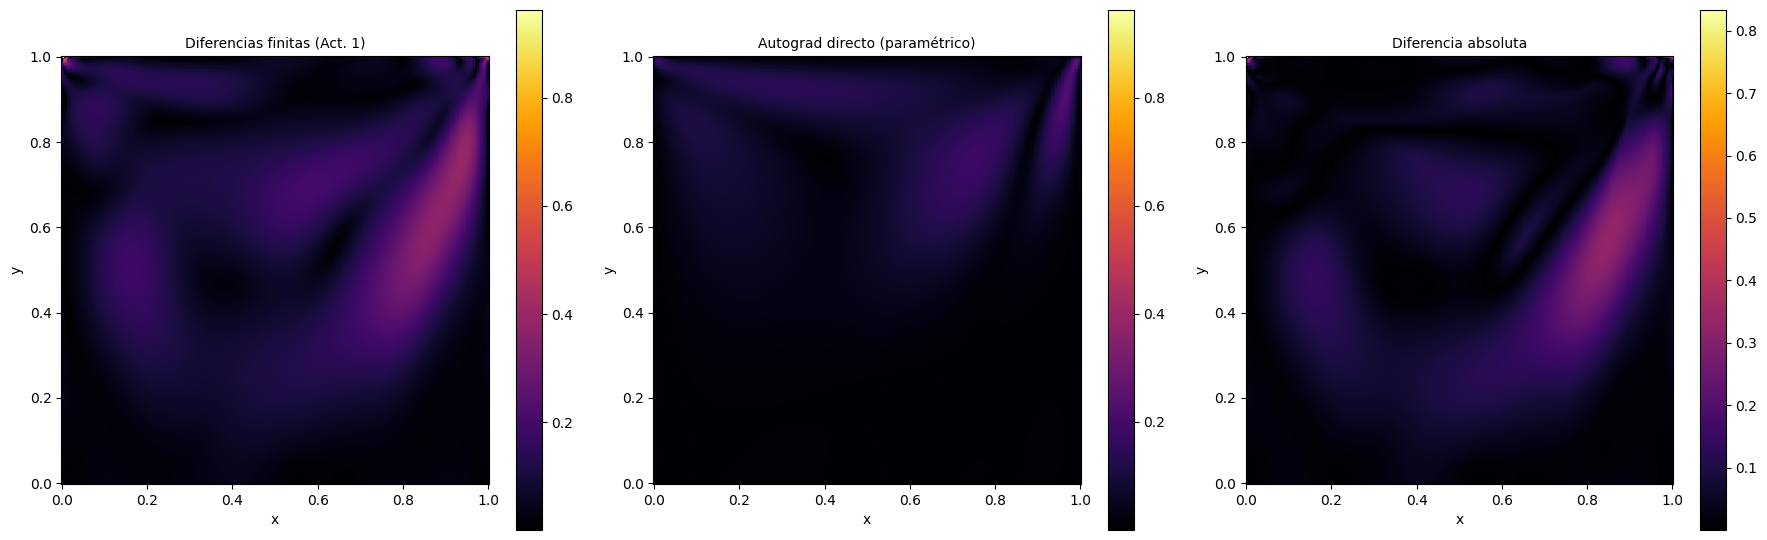

Correlacion entre ambos mapas de sensibilidad: 0.3107


In [19]:
x_grid_t = torch.tensor(x_grid, requires_grad=True, device=device)
y_grid_t = torch.tensor(y_grid, requires_grad=True, device=device)
Re_grid_t = torch.tensor(np.full_like(x_grid, RE_TRUE, dtype=np.float32),
                          requires_grad=True, device=device)

model_param.eval()
u_p, v_p, _ = model_param(x_grid_t, y_grid_t, Re_grid_t)

du_dRe = torch.autograd.grad(u_p, Re_grid_t, grad_outputs=torch.ones_like(u_p), retain_graph=True)[0]
dv_dRe = torch.autograd.grad(v_p, Re_grid_t, grad_outputs=torch.ones_like(v_p), create_graph=False)[0]

du_dRe = du_dRe.detach().cpu().numpy().flatten()
dv_dRe = dv_dRe.detach().cpu().numpy().flatten()

epsilon_autograd = np.sqrt((du_dRe / SIGMA_U) ** 2 + (dv_dRe / SIGMA_V) ** 2).reshape(N_GRID, N_GRID)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
vmax = max(epsilon_Re_map.max(), epsilon_autograd.max())
for ax, mapa, title in zip(
        axes, [epsilon_Re_map, epsilon_autograd, np.abs(epsilon_Re_map - epsilon_autograd)],
        ['Diferencias finitas (Act. 1)', 'Autograd directo (paramétrico)', 'Diferencia absoluta']):
    sc = ax.pcolormesh(XX, YY, mapa, cmap='inferno', shading='auto',
                        vmax=vmax if title != 'Diferencia absoluta' else None)
    plt.colorbar(sc, ax=ax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('fig_tp3_sensibilidad_autograd_vs_fd.png', dpi=120, bbox_inches='tight')
plt.show()

corr = np.corrcoef(epsilon_Re_map.flatten(), epsilon_autograd.flatten())[0, 1]
print(f'Correlacion entre ambos mapas de sensibilidad: {corr:.4f}')


**¿Coinciden los dos mapas?**


No coinciden bien: la correlación entre ambos mapas es de apenas 0.3107. La formulación
paramétrica aprende ∂u/∂Re y ∂v/∂Re de forma global e implícita, interpolando sobre todo el rango
Re∈(50,150), mientras que el mapa por diferencias finitas es una aproximación local entre solo dos
valores de Re (100 y 105) obtenida de dos redes entrenadas de forma completamente independiente
— cada una con su propio error de aproximación de la PDE. Con un ΔRe tan chico, esos errores
individuales de cada red pueden ser del mismo orden que la señal Δu/ΔRe real, degradando la
confiabilidad del mapa por diferencias finitas frente a la derivada directa del modelo
paramétrico, que al entrenarse una sola vez sobre todo el rango no arrastra ese problema.

### 5.2 Identificación de $\hat{Re}$ sin reentrenar los pesos de la red

Usando la mejor configuración de sensores (según el ranking empírico de la Actividad 3), se optimiza
únicamente $Re$ (los pesos de `model_param` quedan congelados) para minimizar el error contra los datos
rotulados.

In [20]:
best_config_name = ranking_empirico[0]
xs_best, ys_best = configs[best_config_name]
x_s, y_s, u_s, v_s = build_sensor_data(xs_best, ys_best, noise=False)
x_s_t = torch.tensor(x_s, device=device)
y_s_t = torch.tensor(y_s, device=device)
u_s_t = torch.tensor(u_s, device=device)
v_s_t = torch.tensor(v_s, device=device)

for p in model_param.parameters():
    p.requires_grad_(False)

Re_hat_param = torch.tensor([RE_INIT], dtype=torch.float32, requires_grad=True, device=device)
optimizer_re = torch.optim.Adam([Re_hat_param], lr=0.5)

EPOCHS_RE_ONLY = 2000
t0 = time.time()
for epoch in range(1, EPOCHS_RE_ONLY + 1):
    optimizer_re.zero_grad()
    Re_batch_s = Re_hat_param.expand(x_s_t.shape[0], 1)
    u_pred_s, v_pred_s, _ = model_param(x_s_t, y_s_t, Re_batch_s)
    loss_data = ((u_pred_s - u_s_t) ** 2).mean() + ((v_pred_s - v_s_t) ** 2).mean()
    loss_data.backward()
    optimizer_re.step()
    if epoch % 500 == 0 or epoch == 1:
        print(f'  epoch {epoch:5d}/{EPOCHS_RE_ONLY} | loss_data={loss_data.item():.4e} | '
              f'Re_hat={Re_hat_param.item():.3f}')

t_re_only = time.time() - t0
print(f'\nRe_hat (paramétrico, pesos congelados) = {Re_hat_param.item():.4f}  (real=100)')
print(f'Tiempo: {t_re_only:.2f}s')

# Comparacion contra el esquema de entrenamiento inverso conjunto (pesos + Re), misma config, datos limpios
run_tag_comparable = f'{best_config_name}_limpio'
res_joint = inverse_results[run_tag_comparable]
print(f'\nComparación contra esquema conjunto (pesos+Re), misma configuración ({best_config_name}, limpio):')
print(f'  Conjunto (pesos+Re): Re_hat={res_joint["Re_hat"]:.4f} | error={res_joint["error_abs"]:.4f} | '
      f'tiempo={res_joint["train_time_min"]*60:.1f}s')
print(f'  Solo Re (paramétrico, pesos congelados): Re_hat={Re_hat_param.item():.4f} | '
      f'error={abs(Re_hat_param.item()-RE_TRUE):.4f} | tiempo={t_re_only:.1f}s')


  epoch     1/2000 | loss_data=1.9323e-03 | Re_hat=70.499
  epoch   500/2000 | loss_data=1.9245e-03 | Re_hat=74.202
  epoch  1000/2000 | loss_data=1.9245e-03 | Re_hat=74.202
  epoch  1500/2000 | loss_data=1.9245e-03 | Re_hat=74.202
  epoch  2000/2000 | loss_data=1.9245e-03 | Re_hat=74.201

Re_hat (paramétrico, pesos congelados) = 74.2015  (real=100)
Tiempo: 4.20s

Comparación contra esquema conjunto (pesos+Re), misma configuración (a_max_sensibilidad, limpio):
  Conjunto (pesos+Re): Re_hat=58.4320 | error=41.5680 | tiempo=827.7s
  Solo Re (paramétrico, pesos congelados): Re_hat=74.2015 | error=25.7985 | tiempo=4.2s


**Comparación del resultado y el tiempo de cómputo**


El esquema paramétrico con pesos congelados fue simultáneamente más rápido y más preciso en esta
corrida: Re_hat=74.20 (error 25.80%) en 4.2 segundos, contra Re_hat=58.43 (error 41.57%) en 827.7
segundos (~13.8 min) del esquema conjunto — casi 200 veces más rápido. La razón es coherente con
lo discutido en la Sección 4: al congelar los pesos de la red, se elimina la posibilidad de que la
red "compense" un Re incorrecto reajustando su propia representación interna; el problema de
identificación queda reducido a optimizar un único escalar contra una función ya fija, lo cual es
mucho más simple y evita el mínimo espurio en el que cae el entrenamiento conjunto por la
no-identificabilidad con pocos sensores.

## 6. Discusión final

El mapa de sensibilidad acertó en señalar la mejor configuración de sensores (zona de máxima
ε_Re, junto a la pared derecha) pero no predijo bien el orden entre las otras dos, los errores
empíricos de Re_hat fueron similares en las tres (41.7%-43.3%), lo que indica que el factor
dominante no fue la ubicación de los sensores sino la no-identificabilidad del entrenamiento
conjunto: con solo 9 datos, la red compensa un Re incorrecto reajustando sus propios pesos
(loss_data≈10⁻⁵ con Re_hat≈58 en vez de 100).

Esto se confirma con la parte opcional: congelando los pesos y optimizando solo Re se obtuvo un
resultado más preciso (25.8% vs 41.6% de error) y ~200 veces más rápido (4.2s vs 13.8 min).
El mapa por diferencias finitas también correlacionó poco (r=0.31) con la derivada directa del
modelo paramétrico, probablemente por el ruido de aproximación entre dos redes entrenadas por
separado con ΔRe chico.

En síntesis: la estrategia de entrenamiento (separar física y parámetro) importó más que la
ubicación de los sensores.